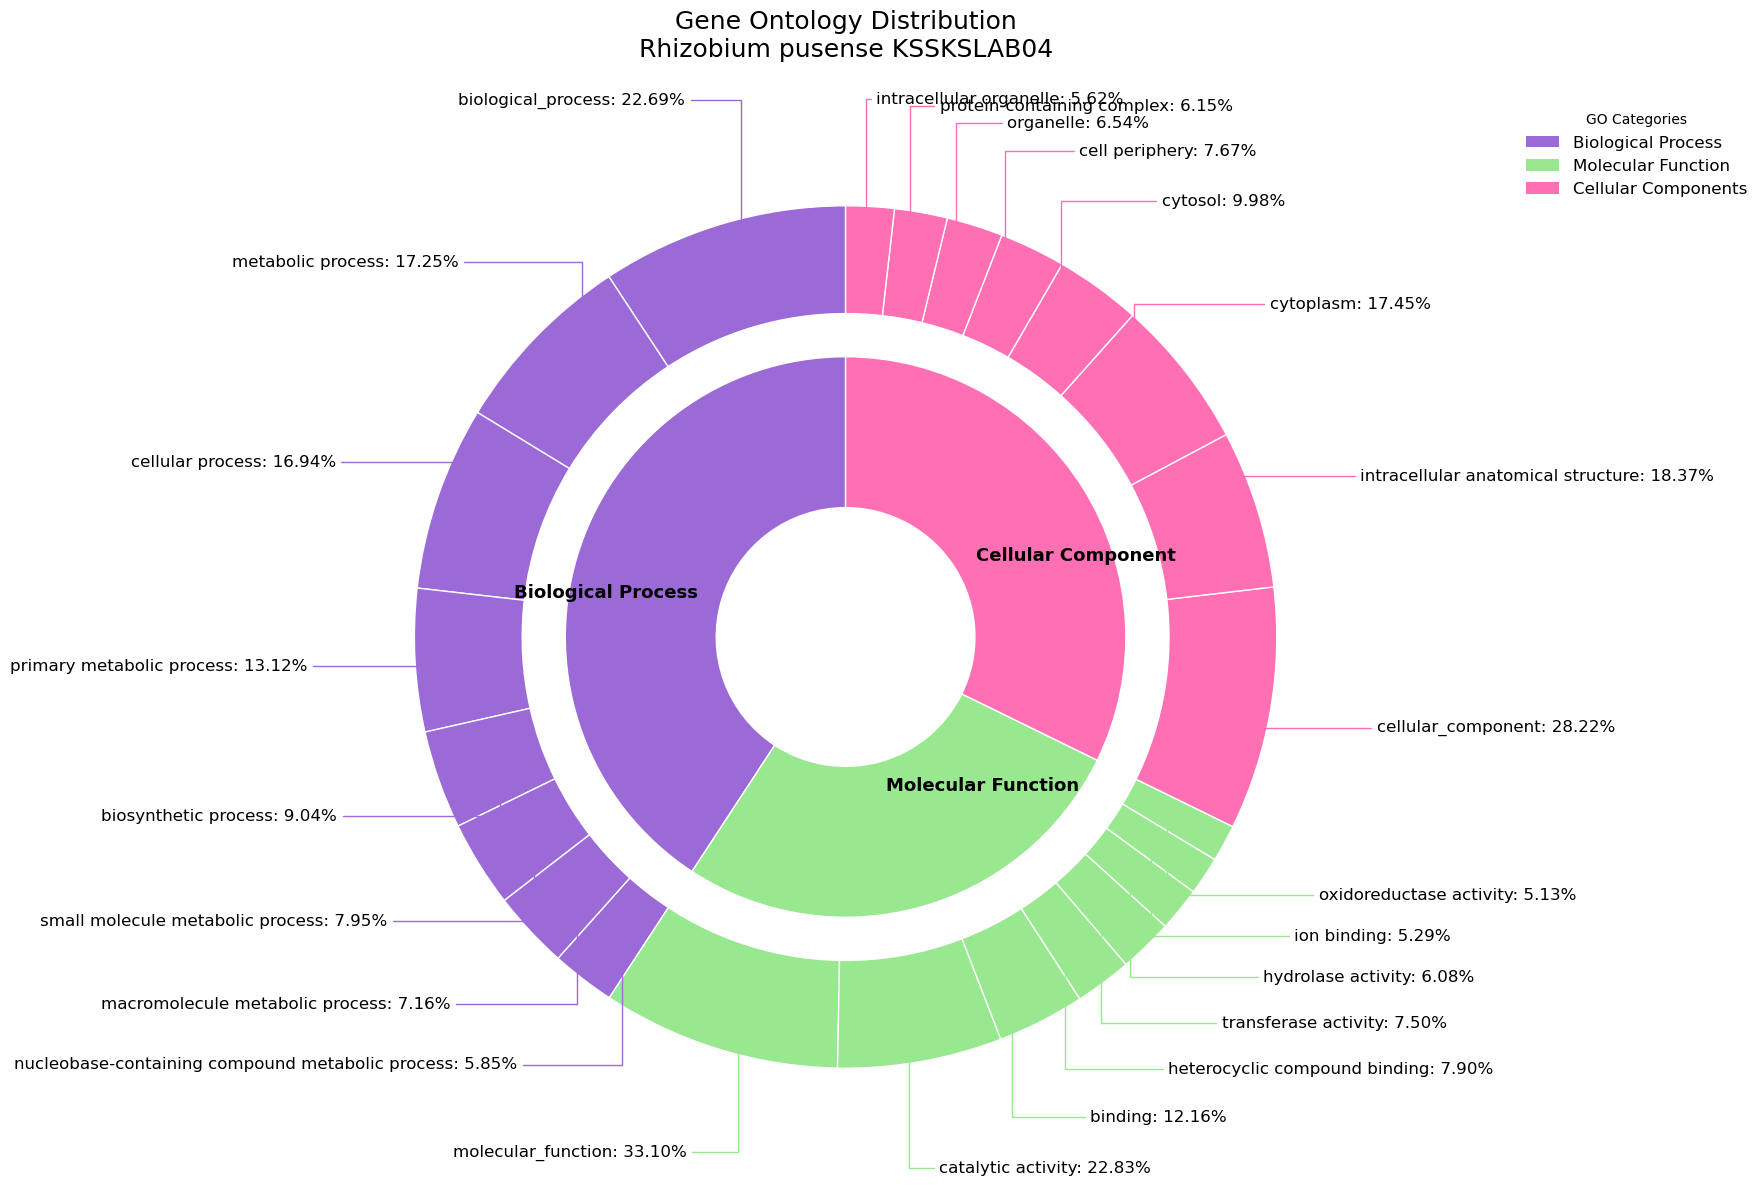

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from goatools.obo_parser import GODag
from matplotlib.patches import Patch
import os

df = pd.read_csv("KSSKSLAB_EGGNOG.emapper.annotations", sep="\t", comment="#", header=None)

go_column = df.iloc[:, 9].dropna()

all_go = []
for entry in go_column:
    if entry != "-":
        all_go.extend(entry.split(","))

counts = Counter(all_go)

bp_counts, mf_counts, cc_counts = {}, {}, {}

for go_id, count in counts.items():
    if go_id not in go_dag:
        continue

    term = go_dag[go_id]
    if term.namespace == "biological_process":
        bp_counts[term.name] = count
    elif term.namespace == "molecular_function":
        mf_counts[term.name] = count
    elif term.namespace == "cellular_component":
        cc_counts[term.name] = count

bp_df = pd.DataFrame(bp_counts.items(), columns=["Term", "Count"]).sort_values("Count", ascending=False).head(8)
mf_df = pd.DataFrame(mf_counts.items(), columns=["Term", "Count"]).sort_values("Count", ascending=False).head(8)
cc_df = pd.DataFrame(cc_counts.items(), columns=["Term", "Count"]).sort_values("Count", ascending=False).head(8)


outer_sizes = list(bp_df["Count"]) + list(mf_df["Count"]) + list(cc_df["Count"])

outer_labels = (
    [f"{t}: {c/sum(bp_df['Count'])*100:.2f}%" for t, c in zip(bp_df["Term"], bp_df["Count"])] +
    [f"{t}: {c/sum(mf_df['Count'])*100:.2f}%" for t, c in zip(mf_df["Term"], mf_df["Count"])] +
    [f"{t}: {c/sum(cc_df['Count'])*100:.2f}%" for t, c in zip(cc_df["Term"], cc_df["Count"])]
)

inner_sizes = [
    bp_df["Count"].sum(),
    mf_df["Count"].sum(),
    cc_df["Count"].sum()
]

inner_labels = [
    "Biological Process",
    "Molecular Function",
    "Cellular Component"
]

bp_color= "#9b6ad6"
mf_color= "#98e890" 
cc_color= "#ff6fb3"


outer_colors = (
    [bp_color] * len(bp_df) +
    [mf_color] * len(mf_df) +
    [cc_color] * len(cc_df)
)

fig, ax = plt.subplots(figsize=(14,14))

wedges, _= ax.pie(outer_sizes, radius=1.0, colors=outer_colors, startangle=90, wedgeprops=dict(width=0.25, edgecolor="white"))
ax.pie(inner_sizes,radius=0.65,labels=inner_labels,colors=[bp_color, mf_color, cc_color],startangle=90,labeldistance=0.55,textprops=dict(fontsize=13, weight="bold"),wedgeprops=dict(width=0.35, edgecolor="white"))

for i, (wedge, label) in enumerate(zip(wedges, outer_labels)):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    ha = "left" if x > 0 else "right"

    # Add small offset for wedges in top region
    r = 1.25
    if angle > 80 and angle < 100:  # near top
        r += 0.08
    elif angle > 70 and angle < 110:  # optional wider top range
        r += 0.05

    ax.annotate(
        label,
        xy=(0.85 * x, 0.85 * y),
        xytext=(r * x, r * y),
        ha=ha,
        va="center",
        fontsize=12,
        arrowprops=dict(
            arrowstyle="-",
            lw=1,
            color=wedge.get_facecolor(),
            connectionstyle="angle,angleA=0,angleB=90"
        )
    )
           

legend_elements =[
    Patch(facecolor=bp_color, edgecolor="none", label= "Biological Process"),
    Patch(facecolor=mf_color, edgecolor="none", label= "Molecular Function"),
    Patch(facecolor=cc_color, edgecolor="none", label= "Cellular Components")
]

ax.legend(handles=legend_elements,loc= "upper right", bbox_to_anchor=(1.35, 1.0),frameon=False,fontsize =12,title= "GO Categories")


plt.title("Gene Ontology Distribution\nRhizobium pusense KSSKSLAB04",fontsize=18, pad=30)

plt.savefig("draft1 ontology plot.png", dpi=300, bbox_inches="tight")
plt.show()

